In [20]:
import torch
import torch.nn as nn
from torchsummary import summary
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchinfo
import numpy as np
import math

from tqdm import tqdm

## Model definition

In [14]:
# creazione del generatore

class Generator(nn.Module):
    def __init__(self, input_dim=100, n1=512, channels=3, width=64, height=64):
        super(Generator, self).__init__()
        
        # Calcola le dimensioni iniziali
        # Per ottenere 64x64 alla fine, partiamo da 4x4
        self.init_size = width // 16  # 64 // 16 = 4
        
        # Layer fully connected per trasformare il rumore in una feature map iniziale
        self.fc = nn.Linear(input_dim, n1 * self.init_size * self.init_size)
        
        # Architettura DCGAN con ConvTranspose2d per upsampling
        self.model = nn.Sequential(
            # Stato: (n1, 4, 4)
            nn.BatchNorm2d(n1),
            
            # Upsampling a 8x8
            nn.ConvTranspose2d(n1, n1 // 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(n1 // 2),
            nn.ReLU(inplace=True),
            
            # Stato: (n1//2, 8, 8)
            # Upsampling a 16x16
            nn.ConvTranspose2d(n1 // 2, n1 // 4, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(n1 // 4),
            nn.ReLU(inplace=True),
            
            # Stato: (n1//4, 16, 16)
            # Upsampling a 32x32
            nn.ConvTranspose2d(n1 // 4, n1 // 8, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(n1 // 8),
            nn.ReLU(inplace=True),
            
            # Stato: (n1//8, 32, 32)
            # Upsampling finale a 64x64
            nn.ConvTranspose2d(n1 // 8, channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh()  # Output in range [-1, 1]
        )
    
    def forward(self, x):
        # x shape: (batch_size, input_dim)
        out = self.fc(x)
        out = out.view(out.size(0), 512, self.init_size, self.init_size)
        img = self.model(out)
        return img


In [ ]:
from torchinfo import summary

NUM_DIMS = 100
image_size = (64, 64)

# Device selection
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print("Using CUDA (NVIDIA GPU)")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print("Using CPU")

gen = Generator(input_dim=NUM_DIMS, n1=512, channels=3, width=image_size[0], height=image_size[1])
gen.to(device)

# torchinfo è più affidabile con MPS
summary(gen, input_size=(1, NUM_DIMS), device=device)


Using MPS (Apple Silicon GPU)


Layer (type:depth-idx)                   Output Shape              Param #
Generator                                [1, 3, 64, 64]            --
├─Linear: 1-1                            [1, 8192]                 827,392
├─Sequential: 1-2                        [1, 3, 64, 64]            --
│    └─BatchNorm2d: 2-1                  [1, 512, 4, 4]            1,024
│    └─ConvTranspose2d: 2-2              [1, 256, 8, 8]            2,097,408
│    └─BatchNorm2d: 2-3                  [1, 256, 8, 8]            512
│    └─ReLU: 2-4                         [1, 256, 8, 8]            --
│    └─ConvTranspose2d: 2-5              [1, 128, 16, 16]          524,416
│    └─BatchNorm2d: 2-6                  [1, 128, 16, 16]          256
│    └─ReLU: 2-7                         [1, 128, 16, 16]          --
│    └─ConvTranspose2d: 2-8              [1, 64, 32, 32]           131,136
│    └─BatchNorm2d: 2-9                  [1, 64, 32, 32]           128
│    └─ReLU: 2-10                        [1, 64, 32, 32] 

In [16]:
# creazione del discriminatore

class Discriminator(nn.Module):
    def __init__(self, width, height, channels, droprate=0.3):
        super(Discriminator, self).__init__()
        
        # Architettura DCGAN per il discriminatore
        self.model = nn.Sequential(
            # Input: (3, 64, 64)
            # Primo layer: NO BatchNorm sul primo layer come da best practices
            nn.Conv2d(channels, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(droprate),
            
            # Stato: (64, 32, 32)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(droprate),
            
            # Stato: (128, 16, 16)
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(droprate),
            
            # Stato: (256, 8, 8)
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(droprate),
            
            # Stato: (512, 4, 4)
            # Layer finale: convoluzione per ridurre a 1x1
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0),
            # Output: (1, 1, 1)
            nn.Sigmoid()  # Output tra 0 e 1 (probabilità)
        )
    
    def forward(self, x):
        # x shape: (batch_size, channels, height, width)
        out = self.model(x)
        # Flatten l'output a (batch_size, 1)
        out = out.view(out.size(0), -1)
        return out

In [ ]:
from torchinfo import summary

disc = Discriminator(width=image_size[0], height=image_size[1], channels=3, droprate=0.3)

# Sposta il modello su MPS
disc.to(device)

# torchinfo supporta MPS nativamente
summary(disc, input_size=(1, 3, image_size[0], image_size[1]), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
Discriminator                            [1, 1]                    --
├─Sequential: 1-1                        [1, 1, 1, 1]              --
│    └─Conv2d: 2-1                       [1, 64, 32, 32]           3,136
│    └─LeakyReLU: 2-2                    [1, 64, 32, 32]           --
│    └─Dropout2d: 2-3                    [1, 64, 32, 32]           --
│    └─Conv2d: 2-4                       [1, 128, 16, 16]          131,200
│    └─BatchNorm2d: 2-5                  [1, 128, 16, 16]          256
│    └─LeakyReLU: 2-6                    [1, 128, 16, 16]          --
│    └─Dropout2d: 2-7                    [1, 128, 16, 16]          --
│    └─Conv2d: 2-8                       [1, 256, 8, 8]            524,544
│    └─BatchNorm2d: 2-9                  [1, 256, 8, 8]            512
│    └─LeakyReLU: 2-10                   [1, 256, 8, 8]            --
│    └─Dropout2d: 2-11                   [1, 256, 8, 8]            --


In [26]:
# Optimizer e Loss Functions

# Discriminator
disc_optimizer = optim.Adam(disc.parameters(), lr=0.0002, betas=(0.5, 0.999))
disc_loss_function = nn.BCELoss()

# Generator
gen_optimizer = optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
gan_loss_function = nn.BCELoss()

In [27]:
# Hyperparameters
LEARNING_RATE = 0.0002
BETA1 = 0.5
BETA2 = 0.999

# Discriminator
disc_optimizer = optim.Adam(
    disc.parameters(), 
    lr=LEARNING_RATE, 
    betas=(BETA1, BETA2)
)
disc_loss_function = nn.BCELoss()

# Generator
gen_optimizer = optim.Adam(
    gen.parameters(), 
    lr=LEARNING_RATE, 
    betas=(BETA1, BETA2)
)
gan_loss_function = nn.BCELoss()

print(f"Optimizers configured with lr={LEARNING_RATE}, betas=({BETA1}, {BETA2})")


Optimizers configured with lr=0.0002, betas=(0.5, 0.999)


##Now define the data loading generator

In [28]:

# add some data augmentation since the dataset size is small
train_transform = transforms.Compose([
    transforms.Resize((image_size[0], image_size[1])),
    transforms.RandomAffine(degrees=0, shear=(-0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [29]:
directory="./Christmas Tree"
import os
training_size = len(os.listdir(directory+"/0") )
print(training_size)

1896


In [30]:
BATCH_SIZE = 128

train_dataset = ImageFolder(root=directory, transform=train_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [32]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils


def plot_figures(x, n):
    plt.imshow(np.transpose(vutils.make_grid(x.to(device)[:n], padding=2, normalize=True).cpu(),(1,2,0)))

    plt.show()


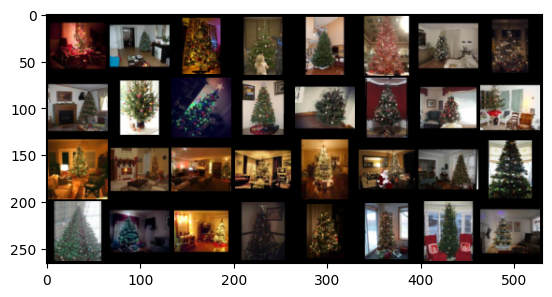

In [33]:
images, _ = next(iter(train_loader))

plot_figures(images, 32)

## Now train for a given number of epochs

In [36]:
from sklearn.utils import shuffle
from imutils import build_montages

import matplotlib.pyplot as plt
from tqdm import tqdm

In [37]:
batchesPerEpoch = int(training_size / BATCH_SIZE)
print(batchesPerEpoch)

14


In [38]:
benchmarkNoise = torch.randn(BATCH_SIZE, NUM_DIMS, device=device)

100%|██████████| 15/15 [00:06<00:00,  2.25it/s]

Epoch 0: D_loss_real=0.2124, D_loss_fake=0.2186, G_loss=3.8123, Acc_real=0.9236, Acc_fake=0.9396


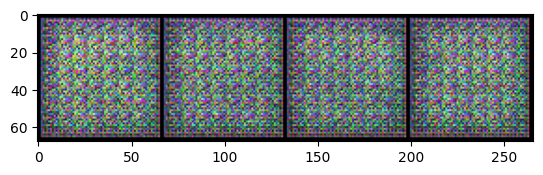

100%|██████████| 15/15 [00:03<00:00,  4.10it/s]


Epoch 1: D_loss_real=0.0902, D_loss_fake=0.0814, G_loss=7.7643, Acc_real=0.9714, Acc_fake=0.9781


100%|██████████| 15/15 [00:03<00:00,  4.23it/s]


Epoch 2: D_loss_real=0.1171, D_loss_fake=0.0983, G_loss=9.1801, Acc_real=0.9560, Acc_fake=0.9635


100%|██████████| 15/15 [00:03<00:00,  4.17it/s]


...

Epoch 8: D_loss_real=0.4805, D_loss_fake=0.4216, G_loss=2.1817, Acc_real=0.7525, Acc_fake=0.8055


100%|██████████| 15/15 [00:03<00:00,  4.21it/s]


Epoch 9: D_loss_real=0.4754, D_loss_fake=0.4531, G_loss=2.1527, Acc_real=0.7708, Acc_fake=0.7940


100%|██████████| 15/15 [00:03<00:00,  4.20it/s]


Epoch 10: D_loss_real=0.5138, D_loss_fake=0.4738, G_loss=2.2346, Acc_real=0.7387, Acc_fake=0.7606


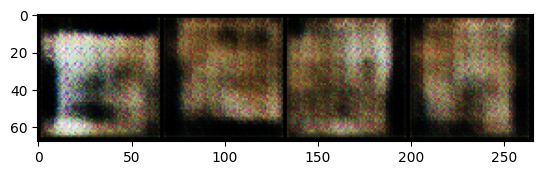

100%|██████████| 15/15 [00:03<00:00,  4.20it/s]


Epoch 11: D_loss_real=0.3913, D_loss_fake=0.3931, G_loss=2.3883, Acc_real=0.8344, Acc_fake=0.8488


100%|██████████| 15/15 [00:03<00:00,  4.20it/s]


Epoch 12: D_loss_real=0.4195, D_loss_fake=0.3566, G_loss=2.4210, Acc_real=0.8185, Acc_fake=0.8616


100%|██████████| 15/15 [00:03<00:00,  4.15it/s]


...

Epoch 18: D_loss_real=0.4017, D_loss_fake=0.3827, G_loss=2.4256, Acc_real=0.8167, Acc_fake=0.8326


100%|██████████| 15/15 [00:03<00:00,  4.18it/s]


Epoch 19: D_loss_real=0.4488, D_loss_fake=0.4246, G_loss=2.4164, Acc_real=0.7965, Acc_fake=0.8118


100%|██████████| 15/15 [00:03<00:00,  4.21it/s]


Epoch 20: D_loss_real=0.3730, D_loss_fake=0.3692, G_loss=2.3588, Acc_real=0.8429, Acc_fake=0.8466


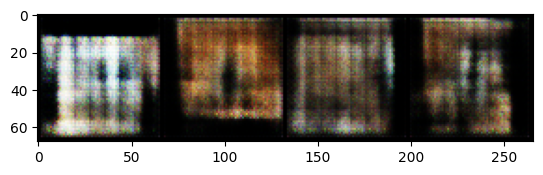

100%|██████████| 15/15 [00:03<00:00,  4.21it/s]


Epoch 21: D_loss_real=0.4199, D_loss_fake=0.3746, G_loss=2.4252, Acc_real=0.8144, Acc_fake=0.8345


100%|██████████| 15/15 [00:03<00:00,  4.20it/s]


Epoch 22: D_loss_real=0.3608, D_loss_fake=0.3873, G_loss=2.6446, Acc_real=0.8473, Acc_fake=0.8274


100%|██████████| 15/15 [00:03<00:00,  4.21it/s]


...

Epoch 28: D_loss_real=0.4764, D_loss_fake=0.4603, G_loss=2.5436, Acc_real=0.7732, Acc_fake=0.7827


100%|██████████| 15/15 [00:03<00:00,  4.09it/s]


Epoch 29: D_loss_real=0.4705, D_loss_fake=0.4381, G_loss=2.3173, Acc_real=0.7770, Acc_fake=0.8010


100%|██████████| 15/15 [00:03<00:00,  4.10it/s]


Epoch 30: D_loss_real=0.4321, D_loss_fake=0.4082, G_loss=2.5152, Acc_real=0.7837, Acc_fake=0.8123


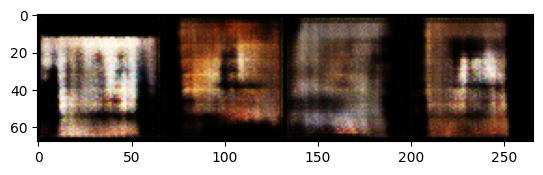

100%|██████████| 15/15 [00:03<00:00,  4.15it/s]


Epoch 31: D_loss_real=0.4928, D_loss_fake=0.5315, G_loss=2.2752, Acc_real=0.7551, Acc_fake=0.7433


100%|██████████| 15/15 [00:03<00:00,  4.16it/s]


Epoch 32: D_loss_real=0.4257, D_loss_fake=0.4166, G_loss=2.2419, Acc_real=0.8109, Acc_fake=0.8216


100%|██████████| 15/15 [00:03<00:00,  4.16it/s]


...

Epoch 38: D_loss_real=0.4061, D_loss_fake=0.4166, G_loss=2.2196, Acc_real=0.8243, Acc_fake=0.8147


100%|██████████| 15/15 [00:03<00:00,  4.23it/s]


Epoch 39: D_loss_real=0.5480, D_loss_fake=0.5090, G_loss=1.9198, Acc_real=0.7104, Acc_fake=0.7508


100%|██████████| 15/15 [00:03<00:00,  4.17it/s]

Epoch 40: D_loss_real=0.4309, D_loss_fake=0.4554, G_loss=2.1575, Acc_real=0.8029, Acc_fake=0.7866


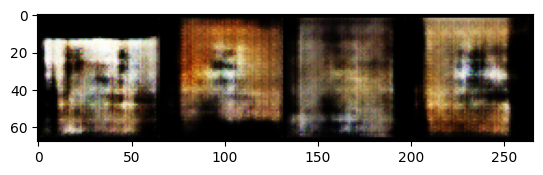

100%|██████████| 15/15 [00:03<00:00,  4.22it/s]


Epoch 41: D_loss_real=0.3873, D_loss_fake=0.4193, G_loss=2.0146, Acc_real=0.8436, Acc_fake=0.8246


100%|██████████| 15/15 [00:03<00:00,  4.25it/s]


Epoch 42: D_loss_real=0.5531, D_loss_fake=0.5177, G_loss=2.3012, Acc_real=0.7113, Acc_fake=0.7401


100%|██████████| 15/15 [00:03<00:00,  4.26it/s]


...

Epoch 48: D_loss_real=0.4929, D_loss_fake=0.5681, G_loss=2.1477, Acc_real=0.7736, Acc_fake=0.7385


100%|██████████| 15/15 [00:03<00:00,  4.25it/s]


Epoch 49: D_loss_real=0.5239, D_loss_fake=0.4742, G_loss=2.0951, Acc_real=0.7373, Acc_fake=0.7729


100%|██████████| 15/15 [00:03<00:00,  4.18it/s]

Epoch 50: D_loss_real=0.4849, D_loss_fake=0.5406, G_loss=2.1437, Acc_real=0.7724, Acc_fake=0.7211


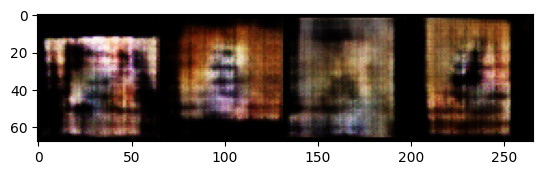

100%|██████████| 15/15 [00:03<00:00,  4.13it/s]


Epoch 51: D_loss_real=0.5101, D_loss_fake=0.4804, G_loss=2.0650, Acc_real=0.7379, Acc_fake=0.7556


100%|██████████| 15/15 [00:03<00:00,  4.20it/s]


Epoch 52: D_loss_real=0.4690, D_loss_fake=0.4715, G_loss=2.1142, Acc_real=0.7972, Acc_fake=0.7772


100%|██████████| 15/15 [00:03<00:00,  4.20it/s]


...

Epoch 58: D_loss_real=0.5169, D_loss_fake=0.5205, G_loss=2.0715, Acc_real=0.7377, Acc_fake=0.7421


100%|██████████| 15/15 [00:03<00:00,  4.04it/s]


Epoch 59: D_loss_real=0.4937, D_loss_fake=0.4218, G_loss=1.8907, Acc_real=0.7607, Acc_fake=0.8147


100%|██████████| 15/15 [00:03<00:00,  4.02it/s]

Epoch 60: D_loss_real=0.4242, D_loss_fake=0.4311, G_loss=1.8340, Acc_real=0.8043, Acc_fake=0.8153


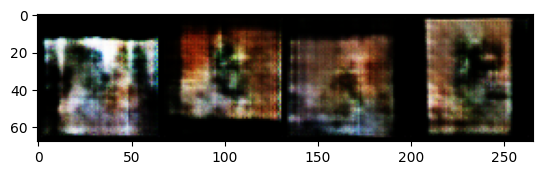

100%|██████████| 15/15 [00:03<00:00,  4.03it/s]


Epoch 61: D_loss_real=0.4681, D_loss_fake=0.4908, G_loss=1.9475, Acc_real=0.7712, Acc_fake=0.7542


100%|██████████| 15/15 [00:03<00:00,  4.03it/s]


Epoch 62: D_loss_real=0.4238, D_loss_fake=0.3690, G_loss=2.1790, Acc_real=0.7993, Acc_fake=0.8442


100%|██████████| 15/15 [00:03<00:00,  4.04it/s]


...

Epoch 68: D_loss_real=0.5065, D_loss_fake=0.5108, G_loss=2.0845, Acc_real=0.7458, Acc_fake=0.7425


100%|██████████| 15/15 [00:03<00:00,  4.04it/s]


Epoch 69: D_loss_real=0.4014, D_loss_fake=0.3896, G_loss=2.1417, Acc_real=0.8316, Acc_fake=0.8307


100%|██████████| 15/15 [00:03<00:00,  4.04it/s]

Epoch 70: D_loss_real=0.5426, D_loss_fake=0.5065, G_loss=1.9771, Acc_real=0.7378, Acc_fake=0.7318


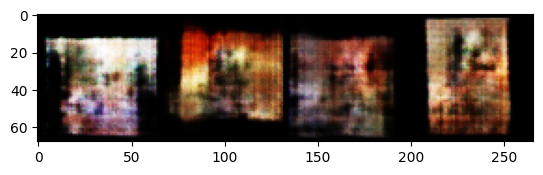

100%|██████████| 15/15 [00:03<00:00,  4.04it/s]


Epoch 71: D_loss_real=0.4938, D_loss_fake=0.4699, G_loss=1.8813, Acc_real=0.7589, Acc_fake=0.7675


100%|██████████| 15/15 [00:03<00:00,  4.03it/s]


Epoch 72: D_loss_real=0.4378, D_loss_fake=0.4242, G_loss=1.8166, Acc_real=0.8071, Acc_fake=0.8167


100%|██████████| 15/15 [00:03<00:00,  4.15it/s]


...

Epoch 78: D_loss_real=0.6176, D_loss_fake=0.5493, G_loss=1.8157, Acc_real=0.6899, Acc_fake=0.7002


100%|██████████| 15/15 [00:03<00:00,  4.21it/s]


Epoch 79: D_loss_real=0.4908, D_loss_fake=0.4947, G_loss=1.7832, Acc_real=0.7440, Acc_fake=0.7594


100%|██████████| 15/15 [00:03<00:00,  4.23it/s]


Epoch 80: D_loss_real=0.5201, D_loss_fake=0.5111, G_loss=1.8194, Acc_real=0.7440, Acc_fake=0.7456


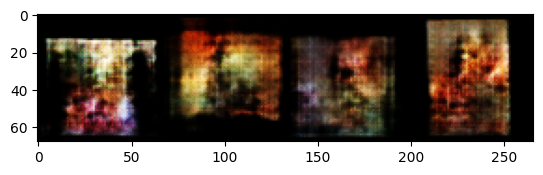

100%|██████████| 15/15 [00:03<00:00,  4.21it/s]


Epoch 81: D_loss_real=0.5781, D_loss_fake=0.5527, G_loss=1.7399, Acc_real=0.7030, Acc_fake=0.7272


100%|██████████| 15/15 [00:03<00:00,  4.13it/s]


Epoch 82: D_loss_real=0.5165, D_loss_fake=0.5101, G_loss=1.7904, Acc_real=0.7627, Acc_fake=0.7556


100%|██████████| 15/15 [00:03<00:00,  4.21it/s]


...

Epoch 88: D_loss_real=0.4771, D_loss_fake=0.5122, G_loss=1.9730, Acc_real=0.7646, Acc_fake=0.7356


100%|██████████| 15/15 [00:03<00:00,  4.10it/s]


Epoch 89: D_loss_real=0.5678, D_loss_fake=0.5056, G_loss=1.8231, Acc_real=0.7016, Acc_fake=0.7415


100%|██████████| 15/15 [00:03<00:00,  4.08it/s]

Epoch 90: D_loss_real=0.5072, D_loss_fake=0.5183, G_loss=1.8328, Acc_real=0.7554, Acc_fake=0.7502


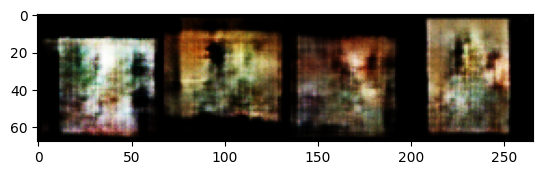

100%|██████████| 15/15 [00:03<00:00,  4.14it/s]


Epoch 91: D_loss_real=0.5043, D_loss_fake=0.5362, G_loss=1.8291, Acc_real=0.7452, Acc_fake=0.7277


100%|██████████| 15/15 [00:03<00:00,  4.22it/s]


Epoch 92: D_loss_real=0.4806, D_loss_fake=0.4330, G_loss=1.7184, Acc_real=0.7693, Acc_fake=0.7998


100%|██████████| 15/15 [00:03<00:00,  4.22it/s]


...

Epoch 98: D_loss_real=0.5776, D_loss_fake=0.5688, G_loss=1.8560, Acc_real=0.7079, Acc_fake=0.7034


100%|██████████| 15/15 [00:03<00:00,  4.22it/s]


Epoch 99: D_loss_real=0.4764, D_loss_fake=0.4737, G_loss=1.7561, Acc_real=0.7812, Acc_fake=0.7643


100%|██████████| 15/15 [00:03<00:00,  4.20it/s]


Epoch 100: D_loss_real=0.5356, D_loss_fake=0.5049, G_loss=1.7696, Acc_real=0.7359, Acc_fake=0.7388


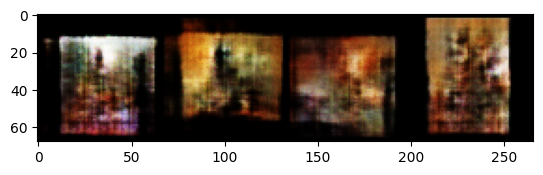

100%|██████████| 15/15 [00:03<00:00,  4.19it/s]


Epoch 101: D_loss_real=0.4449, D_loss_fake=0.4777, G_loss=1.8501, Acc_real=0.8065, Acc_fake=0.7710


100%|██████████| 15/15 [00:03<00:00,  4.22it/s]


Epoch 102: D_loss_real=0.5471, D_loss_fake=0.5917, G_loss=1.8401, Acc_real=0.7085, Acc_fake=0.6801


100%|██████████| 15/15 [00:03<00:00,  4.23it/s]


...

Epoch 108: D_loss_real=0.4695, D_loss_fake=0.4474, G_loss=1.8360, Acc_real=0.7812, Acc_fake=0.7954


100%|██████████| 15/15 [00:03<00:00,  4.23it/s]


Epoch 109: D_loss_real=0.5867, D_loss_fake=0.5492, G_loss=1.8358, Acc_real=0.6940, Acc_fake=0.7186


100%|██████████| 15/15 [00:03<00:00,  4.21it/s]


Epoch 110: D_loss_real=0.5009, D_loss_fake=0.4925, G_loss=2.1197, Acc_real=0.7529, Acc_fake=0.7583


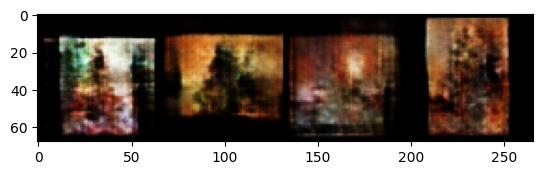

100%|██████████| 15/15 [00:03<00:00,  4.21it/s]


Epoch 111: D_loss_real=0.4871, D_loss_fake=0.5422, G_loss=1.7855, Acc_real=0.7740, Acc_fake=0.7156


100%|██████████| 15/15 [00:03<00:00,  4.22it/s]


Epoch 112: D_loss_real=0.5739, D_loss_fake=0.5243, G_loss=1.6610, Acc_real=0.7036, Acc_fake=0.7347


100%|██████████| 15/15 [00:03<00:00,  4.09it/s]


...

Epoch 118: D_loss_real=0.4532, D_loss_fake=0.4717, G_loss=1.7680, Acc_real=0.7988, Acc_fake=0.7956


100%|██████████| 15/15 [00:03<00:00,  4.20it/s]


Epoch 119: D_loss_real=0.5508, D_loss_fake=0.5419, G_loss=1.7319, Acc_real=0.7242, Acc_fake=0.7216


100%|██████████| 15/15 [00:03<00:00,  4.21it/s]


Epoch 120: D_loss_real=0.4876, D_loss_fake=0.5016, G_loss=1.8903, Acc_real=0.7833, Acc_fake=0.7509


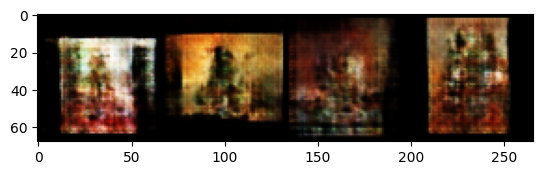

100%|██████████| 15/15 [00:03<00:00,  4.19it/s]


Epoch 121: D_loss_real=0.5114, D_loss_fake=0.4713, G_loss=1.5979, Acc_real=0.7502, Acc_fake=0.7681


100%|██████████| 15/15 [00:03<00:00,  4.23it/s]


Epoch 122: D_loss_real=0.4808, D_loss_fake=0.5674, G_loss=1.9215, Acc_real=0.7739, Acc_fake=0.7005


100%|██████████| 15/15 [00:03<00:00,  4.22it/s]


...

Epoch 128: D_loss_real=0.5001, D_loss_fake=0.4631, G_loss=1.7112, Acc_real=0.7531, Acc_fake=0.7686


100%|██████████| 15/15 [00:03<00:00,  4.21it/s]


Epoch 129: D_loss_real=0.4510, D_loss_fake=0.4541, G_loss=1.8805, Acc_real=0.7862, Acc_fake=0.7734


100%|██████████| 15/15 [00:03<00:00,  4.20it/s]


Epoch 130: D_loss_real=0.4552, D_loss_fake=0.4853, G_loss=1.9178, Acc_real=0.8010, Acc_fake=0.7625


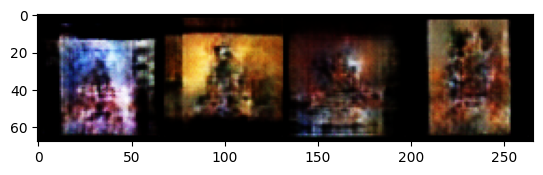

100%|██████████| 15/15 [00:03<00:00,  4.22it/s]


Epoch 131: D_loss_real=0.4776, D_loss_fake=0.4228, G_loss=1.7521, Acc_real=0.7883, Acc_fake=0.8117


100%|██████████| 15/15 [00:03<00:00,  4.22it/s]


Epoch 132: D_loss_real=0.4852, D_loss_fake=0.4963, G_loss=1.7953, Acc_real=0.7727, Acc_fake=0.7494


100%|██████████| 15/15 [00:03<00:00,  4.22it/s]


...

Epoch 138: D_loss_real=0.4901, D_loss_fake=0.4730, G_loss=1.5977, Acc_real=0.7569, Acc_fake=0.7686


100%|██████████| 15/15 [00:03<00:00,  3.99it/s]


Epoch 139: D_loss_real=0.4861, D_loss_fake=0.4859, G_loss=1.8101, Acc_real=0.7662, Acc_fake=0.7628


100%|██████████| 15/15 [00:03<00:00,  4.16it/s]


Epoch 140: D_loss_real=0.4877, D_loss_fake=0.4445, G_loss=1.7339, Acc_real=0.7601, Acc_fake=0.7793


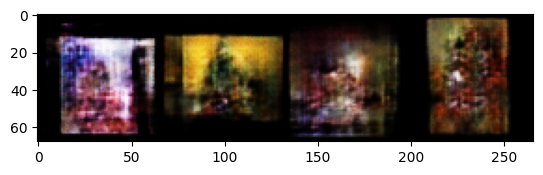

100%|██████████| 15/15 [00:03<00:00,  4.15it/s]


Epoch 141: D_loss_real=0.5175, D_loss_fake=0.6159, G_loss=2.1598, Acc_real=0.7669, Acc_fake=0.6890


100%|██████████| 15/15 [00:03<00:00,  4.21it/s]


Epoch 142: D_loss_real=0.4416, D_loss_fake=0.4168, G_loss=1.8007, Acc_real=0.7991, Acc_fake=0.7960


100%|██████████| 15/15 [00:03<00:00,  4.09it/s]


...

Epoch 148: D_loss_real=0.4839, D_loss_fake=0.4449, G_loss=1.9072, Acc_real=0.7672, Acc_fake=0.7843


100%|██████████| 15/15 [00:03<00:00,  4.19it/s]


Epoch 149: D_loss_real=0.4608, D_loss_fake=0.5133, G_loss=1.8177, Acc_real=0.7879, Acc_fake=0.7501


100%|██████████| 15/15 [00:03<00:00,  4.18it/s]

Epoch 150: D_loss_real=0.5679, D_loss_fake=0.5094, G_loss=1.9630, Acc_real=0.6770, Acc_fake=0.7219


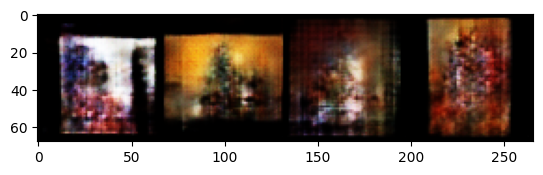

100%|██████████| 15/15 [00:03<00:00,  4.16it/s]


Epoch 151: D_loss_real=0.4843, D_loss_fake=0.5025, G_loss=1.6558, Acc_real=0.7590, Acc_fake=0.7450


100%|██████████| 15/15 [00:03<00:00,  4.16it/s]


Epoch 152: D_loss_real=0.5223, D_loss_fake=0.5099, G_loss=1.7267, Acc_real=0.7508, Acc_fake=0.7490


100%|██████████| 15/15 [00:03<00:00,  4.16it/s]


...

Epoch 158: D_loss_real=0.5238, D_loss_fake=0.5196, G_loss=1.8426, Acc_real=0.7589, Acc_fake=0.7281


100%|██████████| 15/15 [00:03<00:00,  4.13it/s]


Epoch 159: D_loss_real=0.4975, D_loss_fake=0.5130, G_loss=1.6549, Acc_real=0.7659, Acc_fake=0.7359


100%|██████████| 15/15 [00:03<00:00,  4.15it/s]


Epoch 160: D_loss_real=0.4691, D_loss_fake=0.5030, G_loss=1.8396, Acc_real=0.7801, Acc_fake=0.7404


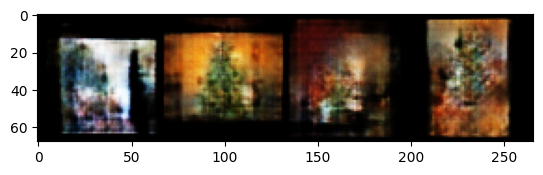

100%|██████████| 15/15 [00:03<00:00,  4.17it/s]


Epoch 161: D_loss_real=0.5497, D_loss_fake=0.4867, G_loss=1.4865, Acc_real=0.7302, Acc_fake=0.7525


100%|██████████| 15/15 [00:03<00:00,  4.17it/s]


Epoch 162: D_loss_real=0.4604, D_loss_fake=0.4666, G_loss=1.9530, Acc_real=0.7920, Acc_fake=0.7764


100%|██████████| 15/15 [00:03<00:00,  4.14it/s]


...

Epoch 168: D_loss_real=0.5400, D_loss_fake=0.5000, G_loss=1.6769, Acc_real=0.7195, Acc_fake=0.7549


100%|██████████| 15/15 [00:03<00:00,  4.13it/s]


Epoch 169: D_loss_real=0.4571, D_loss_fake=0.4779, G_loss=1.7133, Acc_real=0.7976, Acc_fake=0.7764


100%|██████████| 15/15 [00:03<00:00,  4.11it/s]

Epoch 170: D_loss_real=0.5581, D_loss_fake=0.5316, G_loss=1.7629, Acc_real=0.7126, Acc_fake=0.7235


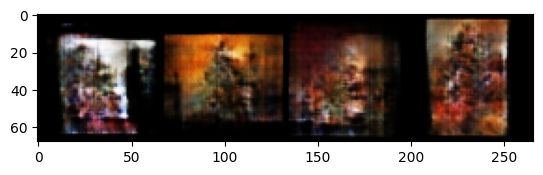

100%|██████████| 15/15 [00:03<00:00,  4.10it/s]


Epoch 171: D_loss_real=0.4624, D_loss_fake=0.4725, G_loss=1.5742, Acc_real=0.7896, Acc_fake=0.7751


100%|██████████| 15/15 [00:03<00:00,  4.09it/s]


Epoch 172: D_loss_real=0.5412, D_loss_fake=0.5286, G_loss=1.7348, Acc_real=0.7141, Acc_fake=0.7010


100%|██████████| 15/15 [00:03<00:00,  3.99it/s]


...

Epoch 178: D_loss_real=0.4800, D_loss_fake=0.5557, G_loss=1.7737, Acc_real=0.7495, Acc_fake=0.7070


100%|██████████| 15/15 [00:03<00:00,  4.22it/s]


Epoch 179: D_loss_real=0.4911, D_loss_fake=0.4319, G_loss=1.5082, Acc_real=0.7684, Acc_fake=0.8153


100%|██████████| 15/15 [00:03<00:00,  4.14it/s]

Epoch 180: D_loss_real=0.4633, D_loss_fake=0.4820, G_loss=1.6902, Acc_real=0.7754, Acc_fake=0.7632


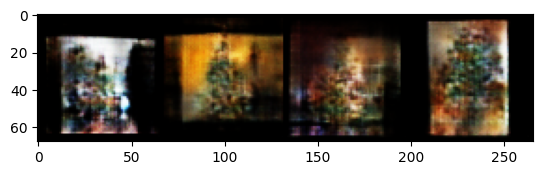

100%|██████████| 15/15 [00:03<00:00,  3.97it/s]


Epoch 181: D_loss_real=0.4973, D_loss_fake=0.5588, G_loss=1.9993, Acc_real=0.7458, Acc_fake=0.6762


100%|██████████| 15/15 [00:03<00:00,  4.12it/s]


Epoch 182: D_loss_real=0.5003, D_loss_fake=0.4551, G_loss=1.8301, Acc_real=0.7464, Acc_fake=0.7740


100%|██████████| 15/15 [00:03<00:00,  4.14it/s]


...

Epoch 188: D_loss_real=0.5112, D_loss_fake=0.5272, G_loss=1.7827, Acc_real=0.7495, Acc_fake=0.7214


100%|██████████| 15/15 [00:03<00:00,  4.21it/s]


Epoch 189: D_loss_real=0.5002, D_loss_fake=0.4880, G_loss=1.6191, Acc_real=0.7600, Acc_fake=0.7599


100%|██████████| 15/15 [00:03<00:00,  4.19it/s]


Epoch 190: D_loss_real=0.4644, D_loss_fake=0.5213, G_loss=1.7468, Acc_real=0.7734, Acc_fake=0.7381


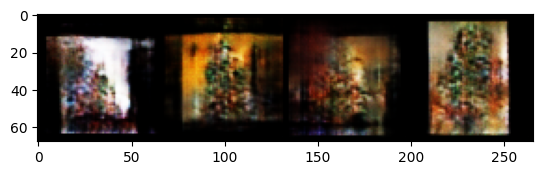

100%|██████████| 15/15 [00:03<00:00,  4.18it/s]


Epoch 191: D_loss_real=0.4758, D_loss_fake=0.4271, G_loss=1.7293, Acc_real=0.7775, Acc_fake=0.8109


100%|██████████| 15/15 [00:03<00:00,  4.22it/s]


Epoch 192: D_loss_real=0.5247, D_loss_fake=0.5402, G_loss=1.5734, Acc_real=0.7163, Acc_fake=0.7089


100%|██████████| 15/15 [00:03<00:00,  4.22it/s]


...

Epoch 197: D_loss_real=0.4556, D_loss_fake=0.4636, G_loss=1.9114, Acc_real=0.7865, Acc_fake=0.7883


100%|██████████| 15/15 [00:03<00:00,  4.04it/s]


Epoch 198: D_loss_real=0.5483, D_loss_fake=0.4884, G_loss=1.7726, Acc_real=0.7303, Acc_fake=0.7423


  7%|▋         | 1/15 [00:00<00:06,  2.05it/s]


KeyboardInterrupt: 

In [41]:
NUM_EPOCHS = 500

history = {}
history['G_loss'] = []
history['D_loss_true'] = []
history['D_loss_fake'] = []
accuracy = {}
accuracy['Acc_true'] = []
accuracy['Acc_fake'] = []

# Labels per il training
real_label = 1.0
fake_label = 0.0

# For each epoch
for epoch in range(NUM_EPOCHS):
    epoch_g_loss = 0.0
    epoch_d_loss_true = 0.0
    epoch_d_loss_fake = 0.0
    epoch_acc_true = 0.0
    epoch_acc_fake = 0.0
    
    # for each batch
    for b, (real_images, _) in enumerate(tqdm(train_loader)):
        batch_size = real_images.size(0)
        
        # Muovi le immagini reali su device
        real_images = real_images.to(device)
        
        # ==========================================
        # 1. TRAIN DISCRIMINATOR con immagini REALI
        # ==========================================
        disc.zero_grad()
        
        # Forward pass con immagini reali
        real_output = disc(real_images)
        real_labels = torch.full((batch_size, 1), real_label, dtype=torch.float, device=device)
        
        # Loss per immagini reali
        disc_loss_real = disc_loss_function(real_output, real_labels)
        disc_loss_real.backward()
        
        # Accuracy su immagini reali
        acc_real = ((real_output > 0.5).float() == real_labels).float().mean()
        
        # ==========================================
        # 2. TRAIN DISCRIMINATOR con immagini FAKE
        # ==========================================
        
        # Sample minibatch of m noise samples
        noise = torch.randn(batch_size, NUM_DIMS, device=device)
        
        # Genera immagini fake
        fake_images = gen(noise)
        fake_labels = torch.full((batch_size, 1), fake_label, dtype=torch.float, device=device)
        
        # Forward pass con immagini fake (detach per non aggiornare il generator)
        fake_output = disc(fake_images.detach())
        
        # Loss per immagini fake
        disc_loss_fake = disc_loss_function(fake_output, fake_labels)
        disc_loss_fake.backward()
        
        # Accuracy su immagini fake
        acc_fake = ((fake_output < 0.5).float() == (1 - fake_labels)).float().mean()
        
        # Update discriminator
        disc_optimizer.step()
        
        # ==========================================
        # 3. TRAIN GENERATOR
        # ==========================================
        gen.zero_grad()
        
        # Sample minibatch of m noise samples (nuovo batch)
        noise = torch.randn(batch_size, NUM_DIMS, device=device)
        
        # Genera immagini fake
        fake_images = gen(noise)
        
        # Forward pass attraverso discriminator (senza detach!)
        # Il generator vuole che il discriminator classifichi le fake come real
        output = disc(fake_images)
        
        # Loss: il generator vuole che l'output sia vicino a 1 (real)
        gan_loss = gan_loss_function(output, real_labels)
        gan_loss.backward()
        
        # Update generator
        gen_optimizer.step()
        
        # ==========================================
        # Accumula metriche
        # ==========================================
        epoch_g_loss += gan_loss.item()
        epoch_d_loss_true += disc_loss_real.item()
        epoch_d_loss_fake += disc_loss_fake.item()
        epoch_acc_true += acc_real.item()
        epoch_acc_fake += acc_fake.item()
    
    # Calcola medie per l'epoca
    num_batches = len(train_loader)
    history['G_loss'].append(epoch_g_loss / num_batches)
    history['D_loss_true'].append(epoch_d_loss_true / num_batches)
    history['D_loss_fake'].append(epoch_d_loss_fake / num_batches)
    accuracy['Acc_true'].append(epoch_acc_true / num_batches)
    accuracy['Acc_fake'].append(epoch_acc_fake / num_batches)
    
    # Print and save model checkpoints
    print(f"Epoch {epoch}: D_loss_real={history['D_loss_true'][-1]:.4f}, D_loss_fake={history['D_loss_fake'][-1]:.4f}, G_loss={history['G_loss'][-1]:.4f}, Acc_real={accuracy['Acc_true'][-1]:.4f}, Acc_fake={accuracy['Acc_fake'][-1]:.4f}")
    
    # Visualize output
    if epoch % 10 == 0:
        gen.eval()
        with torch.no_grad():
            images = gen(benchmarkNoise)
        gen.train()
        # Assuming you have a function plot_figures for visualization
        plot_figures(images, 4)
    
    # save regularly as the training may destabilize and start producing garbage image again
    if (epoch % 100) == 0:
        torch.save({
            'epoch': epoch,
            'disc_state_dict': disc.state_dict(),
            'gen_state_dict': gen.state_dict(),
            'disc_optimizer_state_dict': disc_optimizer.state_dict(),
            'gen_optimizer_state_dict': gen_optimizer.state_dict(),
            'history': history,
            'accuracy': accuracy
        }, f"model64_{epoch}.pth")


In [42]:
import pandas
def plot_losses(history, lim):
  pandas.DataFrame(history).plot(figsize=(10,8))
  plt.grid(True)
  plt.gca().set_ylim(0,lim)
  plt.show()

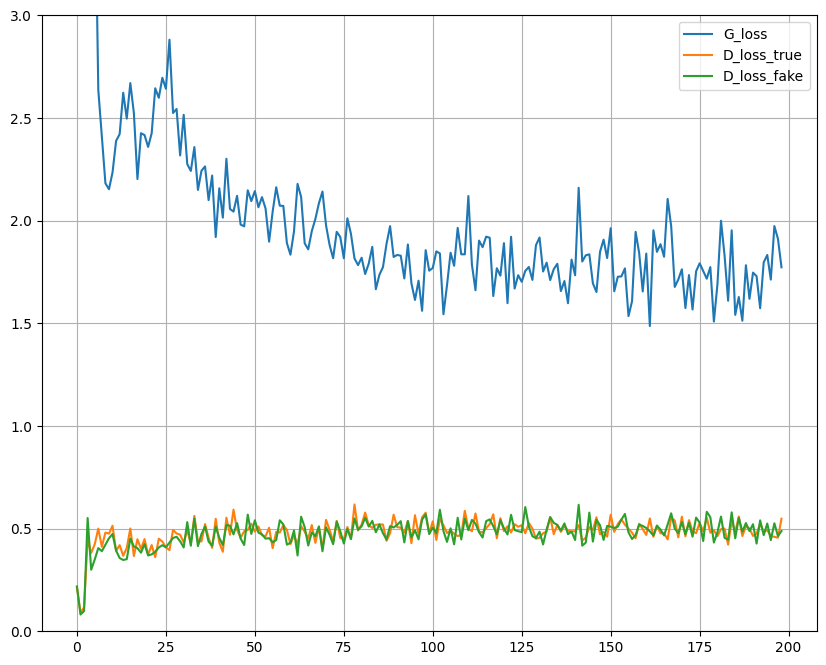

In [43]:
plot_losses(history, 3)


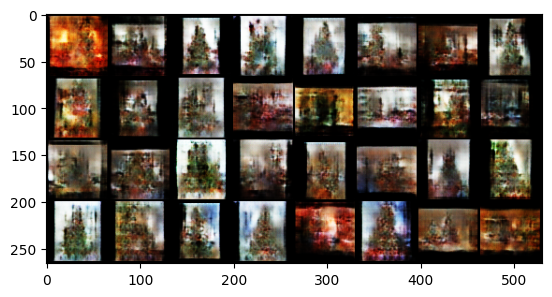

In [44]:
noise = torch.randn(BATCH_SIZE, NUM_DIMS, device=device)
images = gen(noise)
# Assuming you have a function plot_figures for visualization
plot_figures(images, 32)

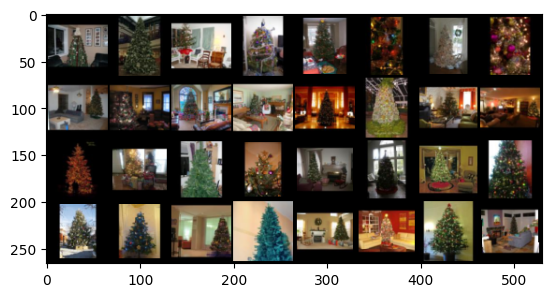

In [45]:
images, _ = next(iter(train_loader))

plot_figures(images, 32)